**Author**: Adrian Vanyi

# Single Backtest Runner

This notebook runs a single backtest of either one of the three long/short equity strategies implemented, with a chosen set of parameters, and outputs the results (plots, table of book values, KPI report, audit logs).

**Strategies available:**
1. `momentum`: long top-k / short bottom-k by momentum signal.
2. `factors_model`: long top-k / short bottom-k from the factors model predicted next-period returns.
3. `mean_variance`: constrained mean-variance optimization (`max-return` or `min-variance`).


**Prerequisite:** the data files (S&P 500 historical members, prices, dividends, SPY, EFFR) must already be in `../data/`. If they are not, run `python download_data.py` from the project root first.

### Notebook structure:
- 0. Setup
- 1. Load pre-downloaded data
- 2. Filter out bad tickers
- 3. Configure the backtest calendar
- 4. Compute risk-free returns
- 5. Build per-rebalance-date universes
- 6. Configure the strategy (select one)
- 7. Configure backtest costs and rules
- 8. Run the backtest
- 9. Plot results
- 10. Book-values table
- 11. Audit logs
- 12. KPIs



## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import pandas as pd
import logging
from modules import logging_setup

from modules import backtest as b
from modules import backtest_calendar as bcal
from modules import beta_computation as bc
from modules import covariance_matrix as cm
from modules import factors_engineering as fe
from modules import kpis
from modules import margin_requirement as mr
from modules import market_data as md
from modules import period_returns as pr
from modules import plotting_results as plot_results
from modules import rates as r
from modules import returns_prediction_model as rpm
from modules import strategies as strat
from modules import trading_utils as tu
from modules import universe_construction as uc
from modules import audit_log

In [4]:
logging_setup.configure(level="INFO", stream = sys.stdout)

logger = logging.getLogger("single_backtest_runner")
logger.setLevel(logging.INFO)

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

## 1. Load pre-downloaded data

If any of these files are missing, run `python download_data.py` from the project root first.

In [5]:
expected_files = [
    "sp500_members_at_start_of_months.parquet",
    "prices_sp500_members.parquet",
    "dividends_data.parquet",
    "daily_spy_returns.parquet",
    "EFFR.csv",
]
missing = [f for f in expected_files if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"data files missing in {DATA_DIR}: {missing}. "
        f"Run `python download_data.py` from the project root first."
    )

# S&P 500 monthly historical members (DataFrame: index=first trading day of
# month, columns are member tickers, eventually extended with NaN to form a uniform width).
sp500_members_at_first_trading_day_of_every_month = pd.read_parquet(
    DATA_DIR / "sp500_members_at_start_of_months.parquet"
)
first_trading_day_of_month_to_sp500_members_dict = {
    idx: row.dropna().tolist()
    for idx, row in sp500_members_at_first_trading_day_of_every_month.iterrows()
}

# Daily price panel for all S&P 500 members during the data window
price_data = pd.read_parquet(DATA_DIR / "prices_sp500_members.parquet")

# Dividend events (long Series indexed by (ticker, ex-dividend date) and values the declared dividend-per-share)
dividend_data = pd.read_parquet(DATA_DIR / "dividends_data.parquet").squeeze()

# SPY adjusted-close prices, used as the market proxy for beta estimation
daily_spy_returns = pd.read_parquet(DATA_DIR / "daily_spy_returns.parquet").squeeze()

# EFFR (Effective Fed Funds Rate), the daily risk-free rate.
effr = (
    pd.read_csv(
        DATA_DIR / "EFFR.csv",
        parse_dates = ["observation_date"],
        date_format = "%d/%m/%Y",
        index_col = 0,
    ).squeeze()
    / 100
)

effr = effr.ffill() 

print(f"price data: {len(price_data):,} (date, ticker) rows")
print(f"dividend events: {len(dividend_data):,}")
print(f"SPY price observations: {len(daily_spy_returns):,}")
print(f"EFFR observations: {len(effr):,}")

price data: 4,362,440 (date, ticker) rows
dividend events: 30,681
SPY price observations: 4,568
EFFR observations: 6,694


In [6]:
price_data

open       close   adj_close        volume
date       ticker                                                  
2008-01-02 A        26.230330   25.965666   22.975681  2.598742e+06
           AA       87.613380   86.820389   72.152649  3.246650e+06
           AAL      14.550000   13.320000   12.557317  3.908000e+06
           AAP      37.910000   37.590000   31.794489  1.789200e+06
           AAPL      7.116786    6.958571    5.832618  1.079179e+09
...                       ...         ...         ...           ...
2026-02-27 ZBH     100.470001   98.440002   98.173409  2.827800e+06
           ZBRA    231.199997  223.960007  223.960007  9.679000e+05
           ZION     60.250000   57.279999   56.847805  3.410400e+06
           ZMH            NaN         NaN         NaN           NaN
           ZTS     128.929993  131.100006  130.532242  5.546300e+06

[4362440 rows x 4 columns]

## 2. Filter out bad tickers

*(see documentation, §6.5 and Apendix A)*

In [7]:
price_data, bad_tickers = uc.remove_bad_tickers(price_data)

close_prices = price_data["close"]

all_tickers_during_backtest = (
    price_data.index.get_level_values("ticker").unique().to_list()
)

print(f"dropped {len(bad_tickers)} bad ticker(s)")

if not bad_tickers.empty:
    print(bad_tickers.head(10))
    
print(f"clean universe: {len(all_tickers_during_backtest)} tickers")

[INFO modules.universe_construction, remove_bad_tickers:287]  removing 84 ticker(s) with bad data (zero_volume=82, extreme_return=16)
dropped 84 bad ticker(s)
        zero_volume  extreme_return
ticker                             
ABI            True           False
AET            True           False
AMCR           True           False
AMD            True           False
ANDV           True           False
BHF            True           False
BKR            True           False
BMC            True            True
BOL            True            True
CA             True           False
clean universe: 871 tickers


## 3. Configure the backtest calendar

*(see documentation, §4)*

In [ ]:
# ---- Rebalance frequency and number of periods 
start = pd.Timestamp("2023-01-05")  # automatically snapped backward to closest trading day, if needed
rebalance_freq_type = "ndays"     # "ndays" or "monthly"
rebalance_frequency_trading_days = 23
number_of_inter_rebalance_periods = 12  # covering ~1 calendar year (given the rebalance frequency of 21 trading days)

# ---- Estimation windows for some of the strategies
rolling_periods_for_cov_matrix_estimation = 18
rolling_periods_for_beta_regression = 12
rolling_periods_for_avg_return_computation = 12
rolling_periods_for_factors_model_regression = 6

number_of_training_inter_rebalance_periods = max(
        rolling_periods_for_factors_model_regression,
        rolling_periods_for_cov_matrix_estimation,
        rolling_periods_for_beta_regression,
        rolling_periods_for_avg_return_computation
    )

# ---- Trading-day rolling windows for daily features  
rolling_window_trading_days_for_volatility = 60
rolling_window_trading_days_for_momentum = 4 * 23   # ~4 trading months
buffer_trading_days_for_momentum = 23                # ~1 trading month skip
rolling_window_trading_days_for_adv = 60             # used only when capping universes


# ---- Build the calendar  
backtest_calendar = bcal.build_calendar(
                            start = start,
                            freq_type = rebalance_freq_type,
                            P = number_of_inter_rebalance_periods,
                            P_train = number_of_training_inter_rebalance_periods,
                            freq = rebalance_frequency_trading_days
                        )

scheduled_rebalance_dates = backtest_calendar.rebalance_dates
scheduled_training_rebalance_dates = backtest_calendar.training_rebalance_dates
backtest_dates = backtest_calendar.backtest_dates

print(
    f"backtest period: {backtest_dates[0]:%Y-%m-%d} to "
    f"{backtest_dates[-1]:%Y-%m-%d} ({len(backtest_dates)} trading days)"
)
print(
    f"rebalance dates: {len(scheduled_rebalance_dates)} "
    f"(training rebalance dates prepended: {len(scheduled_training_rebalance_dates) - len(scheduled_rebalance_dates)})"
)

# ---- Validate that we have enough data history
fetch_start, fetch_end = md.compute_price_data_window(
                                backtest_dates,
                                scheduled_training_rebalance_dates,
                                rolling_window_trading_days_for_momentum,
                                buffer_trading_days_for_momentum,
                                rolling_window_trading_days_for_volatility,
                                rolling_window_trading_days_for_adv
                            )

earliest_supported_date = pd.Timestamp("2008-01-01") # (see documentation, §6.2)
latest_supported_date = pd.Timestamp("2026-02-27")   # choose, at the latest, the last fetch date for price_data

if fetch_start < earliest_supported_date:
    raise ValueError(
        f"backtest needs data back to {fetch_start:%Y-%m-%d}, but earliest "
        f"supported date is {earliest_supported_date:%Y-%m-%d}. Choose a later start."
    )
if fetch_end > latest_supported_date:
    raise ValueError(
        f"backtest extends to {fetch_end:%Y-%m-%d}, but latest supported "
        f"date is {latest_supported_date:%Y-%m-%d}. Reduce P or pick an earlier start."
    )
print(f"data window required: {fetch_start:%Y-%m-%d} to {fetch_end:%Y-%m-%d}")

backtest period: 2023-01-05 to 2024-03-15 (300 trading days)
rebalance dates: 13 (training rebalance dates prepended: 18)
data window required: 2020-11-27 to 2024-03-18


## 4. Compute risk-free returns

*(see documentation, §10)*

In [9]:
r_d = effr / r.ACT_360  

calendar_days_since_previous_trading_date = (
    pd.Series(r_d.index, index=r_d.index)
    - pd.Series(r_d.index, index=r_d.index).shift(1)
).dt.days

rf_daily_returns = (
    (r_d.shift(1) * calendar_days_since_previous_trading_date)
    .rename("rf_return_since_previous_trading_date")
)
rf_daily_returns.index.name = "date"

print(f"rf returns: {rf_daily_returns.dropna().shape[0]:,} non-NaN observations")

rf_daily_returns.tail()

rf returns: 6,693 non-NaN observations


date
2026-02-20    0.000101
2026-02-23    0.000303
2026-02-24    0.000101
2026-02-25    0.000101
2026-02-26    0.000101
Name: rf_return_since_previous_trading_date, dtype: float64

## 5. Build per-rebalance-date universes

*(see documentation, §6)*

In [10]:
capping_num_tickers_per_universe = None  # set to None or to an integer (e.g. 200 to cap at top-200 by ADV)
if capping_num_tickers_per_universe is not None:
    price_data = uc.compute_adv(price_data, adv_window=rolling_window_trading_days_for_adv)


scheduled_reb_date_to_tickers_universe_dict, eligibility_criteria = (
                        uc.build_pit_universes(
                            scheduled_training_rebalance_dates,
                            final_period_end_date = backtest_dates[-1],
                            first_trading_day_of_month_to_sp500_members_dict =(
                                first_trading_day_of_month_to_sp500_members_dict
                            ),
                        price_data = price_data,
                        require_prices_for_next_period = True,
                        capping_num_tickers_per_universe = capping_num_tickers_per_universe,
                        )
)   


first_reb = scheduled_rebalance_dates[0]
last_reb = scheduled_rebalance_dates[-1]
print(
    f"universe size at first rebalance ({first_reb:%Y-%m-%d}): "
    f"{len(scheduled_reb_date_to_tickers_universe_dict[first_reb])}"
)
print(
    f"universe size at last rebalance ({last_reb:%Y-%m-%d}): "
    f"{len(scheduled_reb_date_to_tickers_universe_dict[last_reb])}"
)

print("\n head of dataframe of eligibility criteria: \n")

eligibility_criteria.head()

universe size at first rebalance (2023-01-05): 460
universe size at last rebalance (2024-02-12): 466

 head of dataframe of eligibility criteria: 



forward_close_prices_available  \
training_rebalance_date ticker                                   
2021-05-14              A                                 True   
                        AAL                               True   
                        AAP                               True   
                        AAPL                              True   
                        ABBV                              True   

                                forward_open_prices_available  
training_rebalance_date ticker                                 
2021-05-14              A                                True  
                        AAL                              True  
                        AAP                              True  
                        AAPL                             True  
                        ABBV                             True

## 6. Configure the strategy

Set `strategy_name` to one of:
- `"momentum"` (Strategy 1; *see documentation, §7*)
- `"factors_model"`(Strategy 2; *see documentation, §8*)
- `"mean_variance"`(Strategy 3; *see documentation, §9*)

Common to all strategies:
- set the flag `use_dynamic_rebalancing_rule` to either `True` or `False`. *(see documentation, §5.4)*

In [11]:
# --- Control parameters (set as desired) 
strategy_name = "factors_model"  # "momentum" | "factors_model" | "mean_variance"

use_dynamic_rebalancing_rule = True  # True / False
return_target_for_inter_rebalance_period = 0.03 / 12  # choose any desired target

use_return_target_hit_rule = True  # True / False
return_target_for_strategy = 0.09

# ------

using_fixed_rebalance_calendar = not use_dynamic_rebalancing_rule

last_backtest_date = backtest_dates[-1]

#### Strategy 1: Momentum

In [12]:
if strategy_name == "momentum":
    
    # --- Control parameters (set as desired) 
    top_k_bottom_k = 10  
    shares_per_ticker = 100 
    # ------
    
    if using_fixed_rebalance_calendar:
        precomputed_momentums = fe.compute_momentum_at_training_rebalance_dates(
            prices = close_prices,
            training_rebalance_dates = scheduled_rebalance_dates,
            rolling_window_trading_days = rolling_window_trading_days_for_momentum,
            buffer_trading_days = buffer_trading_days_for_momentum,
            reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict
        )
    else:
        precomputed_momentums = None

    strategy = strat.MomentumStrategy(
        top_k_bottom_k = top_k_bottom_k,
        shares_per_ticker = shares_per_ticker,
        rolling_window_trading_days_for_momentum = rolling_window_trading_days_for_momentum,       
        buffer_trading_days_for_momentum = buffer_trading_days_for_momentum,
        precomputed_momentums = precomputed_momentums
    )
    
    print(f"strategy: {strategy.strategy_name}")

#### Strategy 2: Factors model (long top-k / short bottom-k by predicted returns)

In [13]:
if strategy_name == "factors_model":
    
    # --- Control parameters (set as desired)
    top_k_bottom_k = 10
    shares_per_ticker = 100
    winsorize_factors_per_date = True
    z_score_factors_per_date = True
    use_ridge = False
    ridge_penalty = 0.01
    # ------
    
    if using_fixed_rebalance_calendar:
        # --- computation of the factors:
        factors = fe.compute_factors_at_training_rebalance_dates(
                            prices = close_prices,
                            training_rebalance_dates = scheduled_training_rebalance_dates,
                            rolling_window_trading_days_for_momentum = rolling_window_trading_days_for_momentum,
                            buffer_trading_days_for_momentum = buffer_trading_days_for_momentum,
                            rolling_window_trading_days_for_volatility = rolling_window_trading_days_for_volatility,
                            reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict,
                            winsorize_factors_per_date = winsorize_factors_per_date,
                            z_score_factors_per_date = z_score_factors_per_date
                        )
        
        # --- computation of realized forward returns  
        realized_returns = rpm.compute_realized_period_returns(
                                    prices = close_prices,
                                    training_rebalance_dates = scheduled_training_rebalance_dates,
                                    final_period_end_date = last_backtest_date,
                                    reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict
                                )
        
        model_input = pd.concat([factors, realized_returns], axis=1, join="inner")
        
        factors_model_result = rpm.fit_predict_factors_model_at_rebalance_dates(
                                            rebalance_dates = scheduled_rebalance_dates,
                                            training_rebalance_dates = scheduled_training_rebalance_dates,
                                            model_input = model_input,
                                            rolling_periods = rolling_periods_for_factors_model_regression,
                                            use_ridge = use_ridge ,
                                            ridge_penalty = ridge_penalty
                                        )
        
        precomputed_predictions = factors_model_result.predictions
    else:
        precomputed_predictions = None

    strategy = strat.FactorsModelStrategy(
                            top_k_bottom_k = top_k_bottom_k,
                            shares_per_ticker = shares_per_ticker,
                            training_rebalance_dates = scheduled_training_rebalance_dates,
                            rebalance_freq_type = rebalance_freq_type,
                            rebalance_frequency_trading_days = rebalance_frequency_trading_days,
                            last_backtest_date = last_backtest_date,
                            rolling_window_trading_days_for_momentum = rolling_window_trading_days_for_momentum,
                            buffer_trading_days_for_momentum = buffer_trading_days_for_momentum,
                            rolling_window_trading_days_for_volatility = rolling_window_trading_days_for_volatility,
                            rolling_periods_for_factors_model_regression = rolling_periods_for_factors_model_regression,
                            winsorize_factors_per_date = winsorize_factors_per_date,
                            z_score_factors_per_date = z_score_factors_per_date,
                            precomputed_predictions = precomputed_predictions
                        )
    
    print(f"strategy: {strategy.strategy_name}")

strategy: top_bottom_k_from_factors_model


#### Strategy 3: Mean-variance optimization

In [14]:
if strategy_name == "mean_variance":
    
    # ---- Optimizer targets 
    targets = strat.MVOOptimizerTargets(
        objective = "min_variance",  # "max_return" or "min_variance"
        ptf_variance_cap = 0.04,    # (used when objective="max_return")
        ptf_return_lower_bound = 0.03,    # (used when objective="min_variance")
        ptf_beta_cap = 0.001,
        ptf_net_exposure_cap = 0.001,
        ptf_gross_exposure_cap = 2.0,
        max_shares_per_ticker = 10_000,
    )

    # --- the following is required for estimation method for expected returns ...:
    # ... if using factors_model:
    winsorize_factors_per_date = True
    z_score_factors_per_date = True
    use_ridge = False
    ridge_penalty = 0.01 # (only used when use_ridge == True)
    # ...if using ew_historical_average:
    halflife_ew = 3
    
    estimation = strat.MVOEstimationSettings(
        
        # "factors_model" | "regular_historical_average" | "ew_historical_average"
        next_period_expected_returns_estimation_method = "factors_model",
        
        rolling_periods_for_factors_model_regression = rolling_periods_for_factors_model_regression,
        rolling_window_trading_days_for_momentum = rolling_window_trading_days_for_momentum,
        buffer_trading_days_for_momentum = buffer_trading_days_for_momentum,
        rolling_window_trading_days_for_volatility = rolling_window_trading_days_for_volatility,
        winsorize_factors_per_date = winsorize_factors_per_date,
        z_score_factors_per_date = z_score_factors_per_date,
        rolling_periods_for_avg_return_computation = rolling_periods_for_avg_return_computation,
        avg_type = "regular",  # "regular" or "ew"
        halflife_ew = halflife_ew,
        rolling_periods_for_cov_matrix_estimation = rolling_periods_for_cov_matrix_estimation,
        rolling_periods_for_beta_regression = rolling_periods_for_beta_regression,
    )

    # ---- Precomputed inputs to the optimizer for each rebalance date  (for the fixed backtest rebalance schedule) 
    if using_fixed_rebalance_calendar:
        # estimation of expected returns 
        if estimation.next_period_expected_returns_estimation_method == "factors_model":
            # --- computation of the factors:
            factors = fe.compute_factors_at_training_rebalance_dates(
                    prices = close_prices,
                    training_rebalance_dates = scheduled_training_rebalance_dates,
                    rolling_window_trading_days_for_momentum = rolling_window_trading_days_for_momentum,
                    buffer_trading_days_for_momentum = buffer_trading_days_for_momentum,
                    rolling_window_trading_days_for_volatility = rolling_window_trading_days_for_volatility,
                    reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict,
                    winsorize_factors_per_date = estimation.winsorize_factors_per_date,
                    z_score_factors_per_date = estimation.z_score_factors_per_date,
            )
            # --- computation of realized forward returns 
            realized_returns = rpm.compute_realized_period_returns(
                    prices = close_prices,
                    training_rebalance_dates = scheduled_training_rebalance_dates,
                    final_period_end_date = last_backtest_date,
                    reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict                 
            )
            
            model_input = pd.concat([factors, realized_returns], axis=1, join="inner")
            
            factors_model_result = rpm.fit_predict_factors_model_at_rebalance_dates(
                    rebalance_dates = scheduled_rebalance_dates,
                    training_rebalance_dates = scheduled_training_rebalance_dates,
                    model_input = model_input,
                    rolling_periods = estimation.rolling_periods_for_factors_model_regression,    
                    use_ridge = use_ridge,
                    ridge_penalty = ridge_penalty
            )
            
            mu_predictions = factors_model_result.predictions
            
        else:
            mu_predictions = rpm.rolling_mean_period_returns(
                    prices = close_prices,
                    training_rebalance_dates = scheduled_training_rebalance_dates,
                    rebalance_dates = scheduled_rebalance_dates,
                    rolling_number_of_periods = estimation.rolling_periods_for_avg_return_computation,
                    avg_type = estimation.avg_type,
                    halflife_ew = estimation.halflife_ew
            )

        # estimation of covariance matrices
        cov_result = cm.compute_rolling_cov_matrices(
                prices = close_prices,
                training_rebalance_dates = scheduled_training_rebalance_dates,
                rebalance_dates = scheduled_rebalance_dates,
                rolling_periods_for_estimation = estimation.rolling_periods_for_cov_matrix_estimation,
        )
        cov_matrices = cov_result.matrices

        # estimation of betas
        tickers_betas = bc.compute_capm_betas(
                rf_daily_returns = rf_daily_returns,
                market_daily_returns = daily_spy_returns,
                training_rebalance_dates = scheduled_training_rebalance_dates,
                rebalance_dates = scheduled_rebalance_dates,
                prices = close_prices,
                rolling_periods_for_beta_regression = estimation.rolling_periods_for_beta_regression
        )

        precomputed = strat.MVOPrecomputedInputs(
            expected_returns_predictions_at_reb_dates = mu_predictions,
            cov_matrices_at_reb_dates = cov_matrices,
            tickers_betas_at_reb_dates = tickers_betas
        )
        
    else:
        precomputed = strat.MVOPrecomputedInputs()

    strategy = strat.MeanVarianceOptimizationStrategy(
            targets = targets,
            estimation = estimation,
            precomputed = precomputed,
            rebalance_freq_type = rebalance_freq_type,
            rebalance_frequency_trading_days = rebalance_frequency_trading_days,
            last_backtest_date = last_backtest_date,
            rf_daily_returns = rf_daily_returns,
            market_daily_returns = daily_spy_returns
    )
    print(f"strategy: {strategy.strategy_name} (objective: {targets.objective})")

## 7. Configure backtest costs and rules

In [15]:
# ---- Margin haircuts (see documentation, §3.2) 
mr_haircuts = mr.MRHaircuts(
        backtest_dates = backtest_dates,
        tickers = all_tickers_during_backtest,
        initial_long_haircut = 0.5,
        initial_short_haircut = 0.5,
        maintenance_long_haircut = 0.25,
        maintenance_short_haircut = 0.30
)

In [16]:
# ---- Daily financing rates  (see documentation, §2.6.1)
broker_markup_cash_rate = -0.0042   # (floored at 0)
broker_markup_debit_rate = 0.0300   
annual_cash_interest_rate = effr + broker_markup_cash_rate
annual_debit_rate = effr + broker_markup_debit_rate
annual_margin_collateral_rate = 0.0  
annual_borrow_fee = 0.0025            
annual_rebate_rate = 0.0            

daily_financing_rates = r.DailyFinancingRates(
        backtest_dates = backtest_dates,
        annual_cash_rate = annual_cash_interest_rate,
        annual_debit_rate = annual_debit_rate,
        annual_margin_collateral_rate = annual_margin_collateral_rate,
        annual_borrow_fee = annual_borrow_fee,
        annual_rebate_rate = annual_rebate_rate,
        day_count_basis = r.ACT_360
)

In [17]:
# ---- Trading costs (see documentation, §2.5.2)
trading_costs = tu.TradingCosts(
        backtest_dates = backtest_dates,
        tickers = all_tickers_during_backtest,
        default_slippage_bps = 3.0 , 
        default_full_spread_bps = 2.0,
        default_commission_per_share = 0.001  
)

In [18]:
# ---- Initial capital, method for curing MR violations (doc., §3), and termination rules (doc., §5) 
initial_cash = 100_000.0

cure_method_for_MR_violation = "shrinking_exposures" # "shrinking_exposures" or "posting_collateral"

# Stop-loss fires when equity-excluding-collateral drops to this fraction of initial
pct_initial_equity_triggering_stop_loss = 0.50

## 8. Run the backtest

In [19]:
schedule = b.BacktestSchedule(
        backtest_dates = backtest_dates,
        scheduled_rebalance_dates = scheduled_rebalance_dates,
        scheduled_reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict,
        first_trading_day_of_month_to_sp500_members_dict = first_trading_day_of_month_to_sp500_members_dict,
        scheduled_rebalance_freq_type = rebalance_freq_type,
        scheduled_rebalance_frequency_trading_days = rebalance_frequency_trading_days,
        scheduled_number_of_inter_rebalance_periods_for_backtest = len(scheduled_rebalance_dates) - 1,
        capping_num_tickers_per_universe = capping_num_tickers_per_universe
)

data = b.BacktestData(
        price_data = price_data,
        dividend_data = dividend_data,
        trading_costs = trading_costs,
        daily_financing_rates = daily_financing_rates,
        mr_haircuts = mr_haircuts
)

rules = b.BacktestRules(
        initial_cash = initial_cash,
        use_return_target_hit_rule = use_return_target_hit_rule,
        return_target_for_strategy = return_target_for_strategy,
        use_dynamic_rebalancing_rule = use_dynamic_rebalancing_rule,
        return_target_for_inter_rebalance_period = return_target_for_inter_rebalance_period,
        cure_method_for_MR_violation = cure_method_for_MR_violation,
        pct_initial_equity_triggering_stop_loss = pct_initial_equity_triggering_stop_loss
)

backtest_parameters = b.BacktestParameters(
        strategy = strategy, 
        schedule = schedule, 
        data = data, 
        rules = rules
)

backtest_results = b.run_backtest(backtest_parameters)

print(
    f"\nbacktest finished: {len(backtest_results.book_at_date)} dates, "
    f"{len(backtest_results.actual_rebalance_dates)} actual rebalance(s)"
)

[INFO modules.backtest, run_backtest:697]  backtest started at rebalance date 2023-01-05
[INFO modules.backtest, run_backtest:775]  (2023-02-02) hit inter-rebalance return target; rebalancing today, ahead of schedule
[INFO modules.backtest, run_backtest:775]  (2023-02-15) hit inter-rebalance return target; rebalancing today, ahead of schedule
[INFO modules.backtest, run_backtest:794]  (2023-03-21) scheduled rebalance date
[INFO modules.backtest, run_backtest:794]  (2023-04-24) scheduled rebalance date
[INFO modules.backtest, run_backtest:775]  (2023-04-25) hit inter-rebalance return target; rebalancing today, ahead of schedule
[INFO modules.backtest, run_backtest:775]  (2023-04-26) hit inter-rebalance return target; rebalancing today, ahead of schedule
[INFO modules.backtest, run_backtest:775]  (2023-05-23) hit inter-rebalance return target; rebalancing today, ahead of schedule
[INFO modules.backtest, run_backtest:775]  (2023-05-25) hit inter-rebalance return target; rebalancing today,

## 9. Plot results

In [20]:
book_at_date = backtest_results.book_at_date
actual_backtest_dates = sorted(book_at_date.keys())

plot_start_date = actual_backtest_dates[0]
plot_end_date = actual_backtest_dates[-1]

### 9.1 Equity & drawdowns

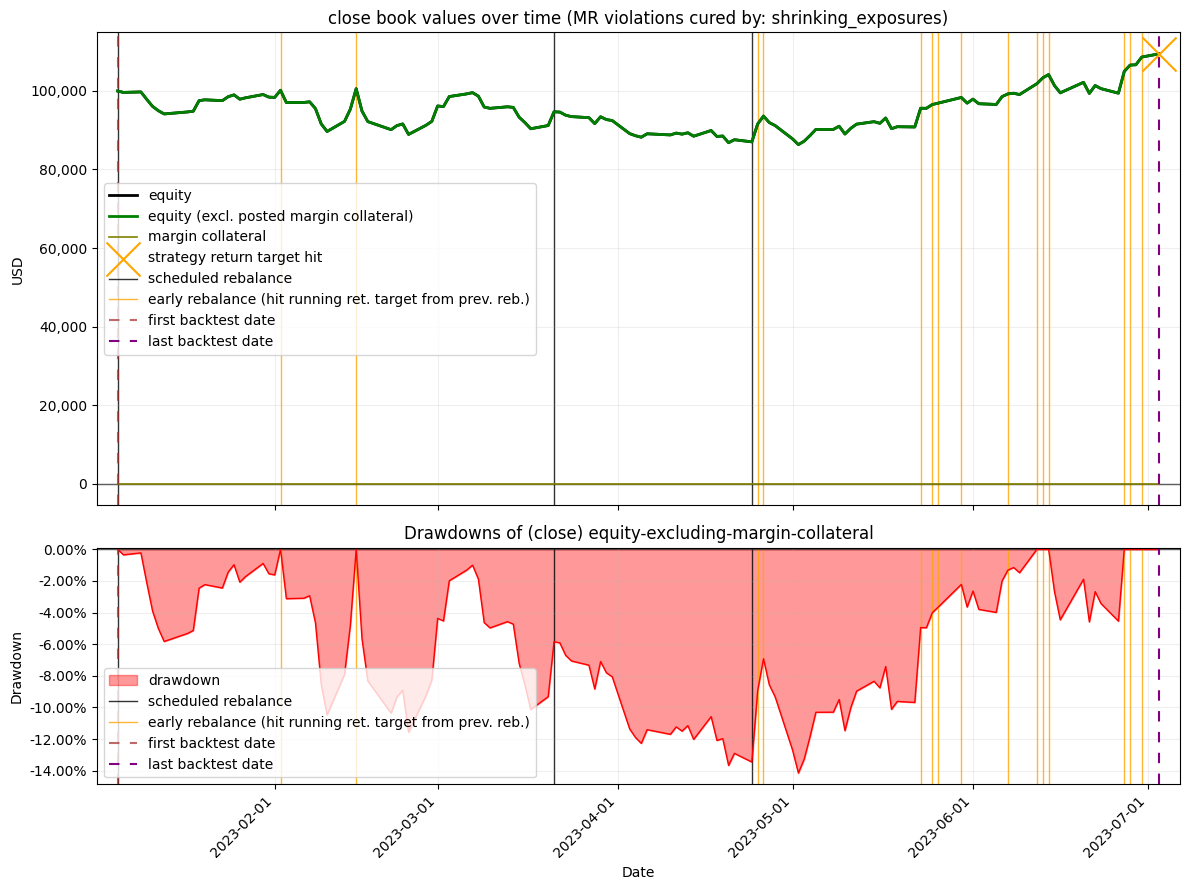

(<Figure size 1200x900 with 2 Axes>,
 [<Axes: title={'center': 'close book values over time (MR violations cured by: shrinking_exposures)'}, ylabel='USD'>,
  <Axes: title={'center': 'Drawdowns of (close) equity-excluding-margin-collateral'}, xlabel='Date', ylabel='Drawdown'>])

In [21]:
plot_results.plot_book_values(
        backtest_results,
        plot_results.PlotConfig(
                plot_start_date = plot_start_date,
                plot_end_date = plot_end_date,
                main_panel = plot_results.MainPanelConfig(
                        show_equity = True,
                        show_equity_excluding_margin_collateral = True,
                        show_collateral = True
                ),
                show_drawdowns = True,
                show_two_snapshots = False,
                show_markers = False,
        )
)

### 9.2 Equity & margin requirement

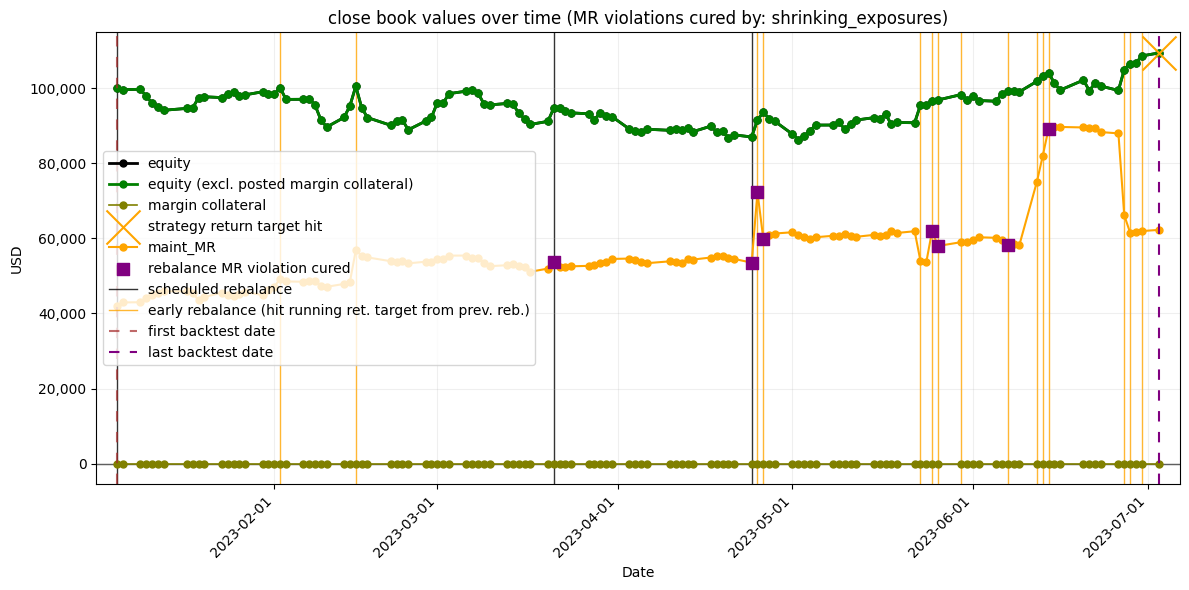

(<Figure size 1200x600 with 1 Axes>,
 [<Axes: title={'center': 'close book values over time (MR violations cured by: shrinking_exposures)'}, xlabel='Date', ylabel='USD'>])

In [22]:
plot_results.plot_book_values(
        backtest_results,
        plot_results.PlotConfig(
                plot_start_date = plot_start_date,
                plot_end_date = plot_end_date,
                main_panel = plot_results.MainPanelConfig(
                        show_equity = True,
                        show_equity_excluding_margin_collateral = True,
                        show_collateral = True,
                        show_margin_requirement = True
                ),
                show_two_snapshots = False,
                show_markers = True
        )
)

### 9.3 LMV / SMV / total short proceeds + leverage ratios

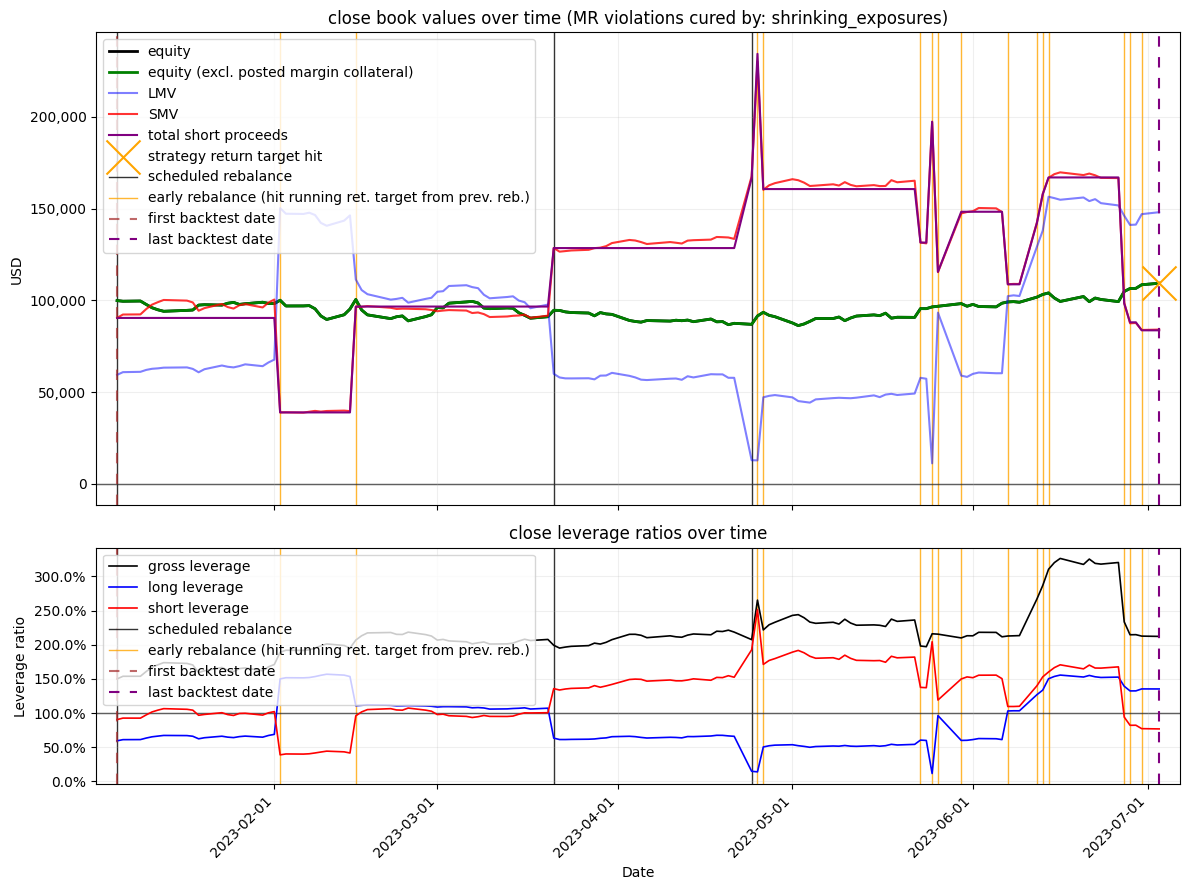

(<Figure size 1200x900 with 2 Axes>,
 [<Axes: title={'center': 'close book values over time (MR violations cured by: shrinking_exposures)'}, ylabel='USD'>,
  <Axes: title={'center': 'close leverage ratios over time'}, xlabel='Date', ylabel='Leverage ratio'>])

In [23]:
plot_results.plot_book_values(
        backtest_results,
        plot_results.PlotConfig(
                plot_start_date = plot_start_date,
                plot_end_date = plot_end_date,
                main_panel = plot_results.MainPanelConfig(
                        show_equity = True,
                        show_equity_excluding_margin_collateral = True,
                        show_LMV = True,
                        show_SMV = True,
                        show_total_short_proceeds = True
                ),
                leverage_panel = plot_results.LeveragePanelConfig(show_all=True),
                show_two_snapshots = False,
                show_markers = False
        )
)

### Zoomed-in for closer inspection, showing the two-snapshots book values

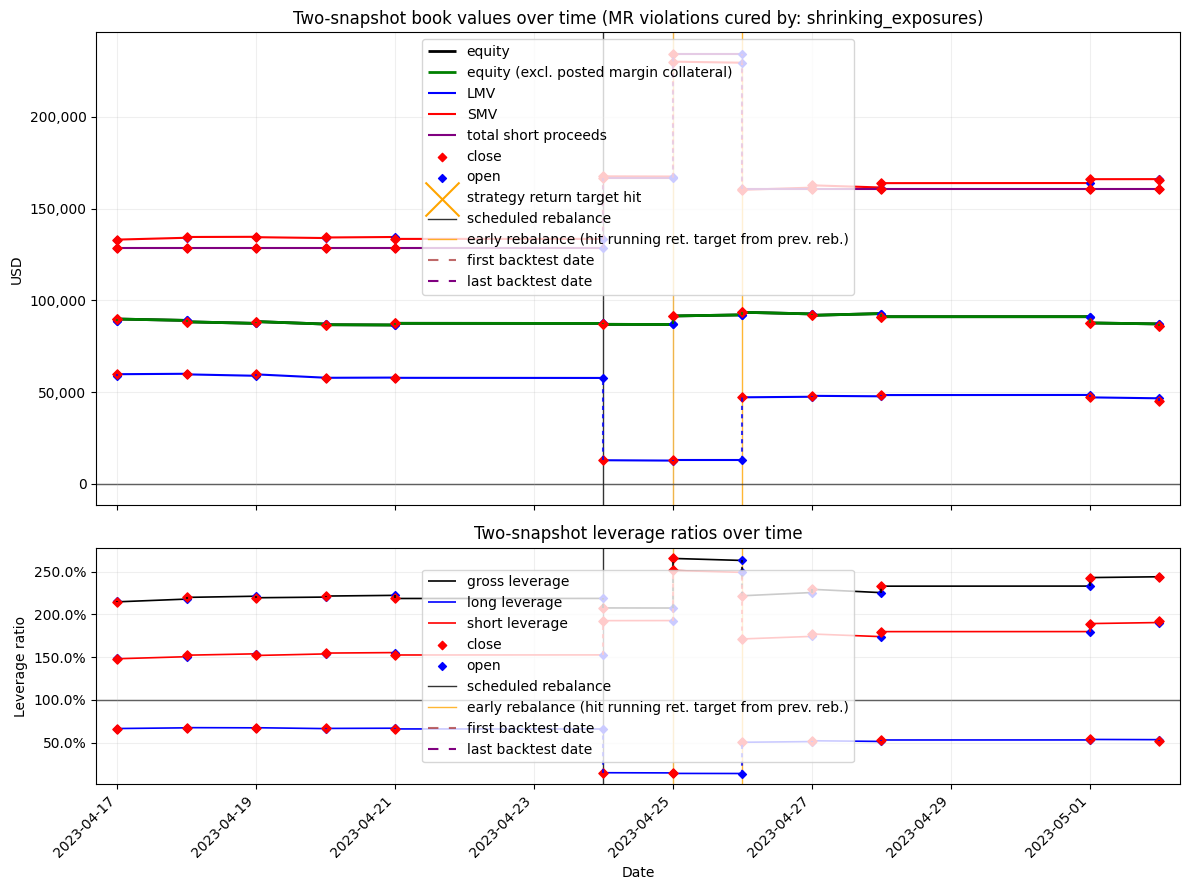

(<Figure size 1200x900 with 2 Axes>,
 [<Axes: title={'center': 'Two-snapshot book values over time (MR violations cured by: shrinking_exposures)'}, ylabel='USD'>,
  <Axes: title={'center': 'Two-snapshot leverage ratios over time'}, xlabel='Date', ylabel='Leverage ratio'>])

In [24]:
plot_start_date = actual_backtest_dates[69]
plot_end_date = actual_backtest_dates[80]

plot_results.plot_book_values(
        backtest_results,
        plot_results.PlotConfig(
                plot_start_date = plot_start_date,
                plot_end_date = plot_end_date,
                main_panel = plot_results.MainPanelConfig(
                        show_equity = True,
                        show_equity_excluding_margin_collateral = True,
                        show_LMV = True,
                        show_SMV = True,
                        show_total_short_proceeds = True
                ),
                leverage_panel = plot_results.LeveragePanelConfig(show_all=True),
                show_two_snapshots = True,
                show_markers = True
        )
)


### 9.4 Cash, debit & equity

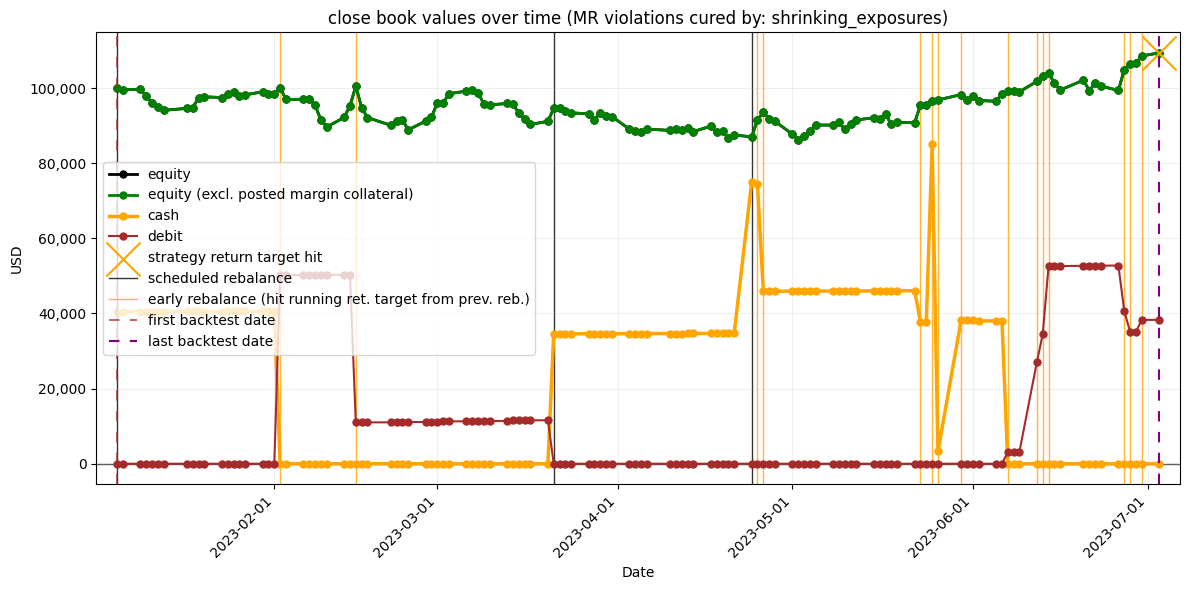

(<Figure size 1200x600 with 1 Axes>,
 [<Axes: title={'center': 'close book values over time (MR violations cured by: shrinking_exposures)'}, xlabel='Date', ylabel='USD'>])

In [25]:
plot_start_date = backtest_dates[0]
plot_end_date = backtest_dates[-1]

plot_results.plot_book_values(
        backtest_results,
        plot_results.PlotConfig(
                plot_start_date = plot_start_date,
                plot_end_date = plot_end_date,
                main_panel = plot_results.MainPanelConfig(
                        show_equity = True,
                        show_equity_excluding_margin_collateral = True,
                        show_cash = True,
                        show_debit = True
                ),
                show_two_snapshots = False,
                show_markers = True
        )
)

### Zoomed-in for closer inspection, showing the two-snapshots book values

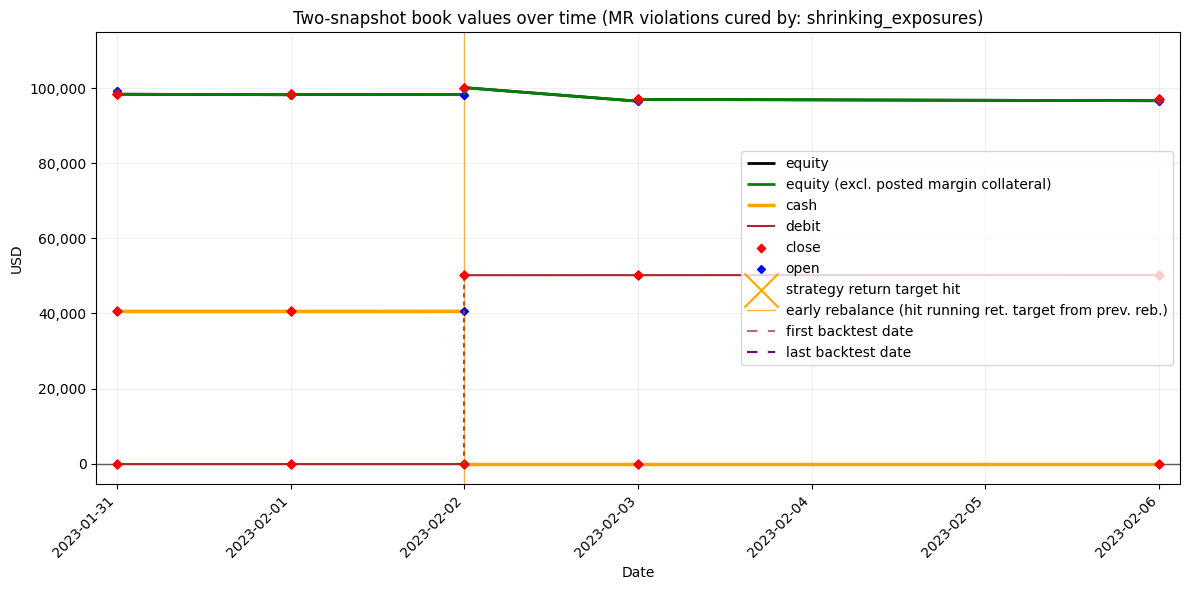

(<Figure size 1200x600 with 1 Axes>,
 [<Axes: title={'center': 'Two-snapshot book values over time (MR violations cured by: shrinking_exposures)'}, xlabel='Date', ylabel='USD'>])

In [26]:
plot_start_date = backtest_dates[17]
plot_end_date = backtest_dates[21]

plot_results.plot_book_values(
        backtest_results,
        plot_results.PlotConfig(
                plot_start_date = plot_start_date,
                plot_end_date = plot_end_date,
                main_panel = plot_results.MainPanelConfig(
                        show_equity = True,
                        show_equity_excluding_margin_collateral = True,
                        show_cash = True,
                        show_debit = True
                ),
                show_two_snapshots = True,
                show_markers = True
        )
)

## 10. Book-values table

In [27]:
book_table = kpis.build_book_ledger_across_dates(backtest_results)
n_rows = 15 # set to None to display all rows
kpis.show_book(book_table.iloc[:n_rows])

## 11. Audit logs
**Saved to disk.**

*(see documentation, §12.9)*

In [28]:
audit_log.log_trades(
    OUTPUTS_DIR / "trades.txt", backtest_results,
)
audit_log.log_position_changes(
    OUTPUTS_DIR / "position_changes.txt", backtest_results,
)
audit_log.log_short_proceeds_changes(
    OUTPUTS_DIR / "short_proceeds_changes.txt", backtest_results,
)

print(f"audit logs written to {OUTPUTS_DIR}")

audit logs written to C:\Users\Adrian\LongShortEquityBacktester\outputs


## 12. KPIs

*(see documentation, §11)*

In [29]:
backtest_kpis = kpis.compute_backtest_kpis(
    backtest_results = backtest_results,
    rf_daily_returns = rf_daily_returns
)

###  Inter-rebalance period returns

In [30]:
n_rows = None  # set to None to display all rows
kpis.style_returns_df(backtest_kpis.period_returns.iloc[:n_rows])

,previous_period_equity_returns,previous_period_rf_returns,previous_period_equity_excess_returns
rebalance dates (except last date),,,
2023-01-05,N/A,N/A,N/A
2023-02-02,0.20%,0.337%,-0.14%
2023-02-15,0.40%,0.165%,0.23%
2023-03-21,-5.85%,0.433%,-6.28%
2023-04-24,-8.08%,0.456%,-8.53%
2023-04-25,5.23%,0.013%,5.21%
2023-04-26,2.21%,0.013%,2.19%
2023-05-23,2.12%,0.376%,1.74%
2023-05-25,0.98%,0.028%,0.96%


###  Returns between consecutive backtest dates

In [31]:
n_rows = 15 # set to None to display all rows
kpis.style_returns_df(backtest_kpis.returns_between_backtest_dates.iloc[:n_rows])

,equity_return_since_previous_backtest_date,rf_return_since_previous_backtest_date,equity_excess_return_since_previous_backtest_date
backtest dates,,,
2023-01-05,N/A,0.012%,N/A
2023-01-06,-0.35%,0.012%,-0.36%
2023-01-09,0.12%,0.036%,0.09%
2023-01-10,-1.88%,0.012%,-1.89%
2023-01-11,-1.83%,0.012%,-1.84%
2023-01-12,-1.16%,0.012%,-1.17%
2023-01-13,-0.86%,0.012%,-0.87%
2023-01-17,0.54%,0.012%,0.52%
2023-01-18,0.20%,0.012%,0.19%


###  KPI  report

**Display report**

In [32]:
kpis.print_kpi_summary(backtest_kpis)


--------------------------------------------------------------------------------
                                    STRATEGY                                    
--------------------------------------------------------------------------------
  strategy_name                                  top_bottom_k_from_factors_model
  return_target_for_strategy                                               9.00%
  inter_rebalance_periods_of_same_duration                                    no
  return_target_for_inter_rebalance_period                                 0.25%
  strategy_parameters:
    top_k_bottom_k                                                            10
    shares_per_ticker                                                        100
    rolling_window_trading_days_for_momentum                                  92
    buffer_trading_days_for_momentum                                          23
    rolling_window_trading_days_for_volatility                                60
    

**Save to disk**

In [33]:
kpis.save_kpi_summary(backtest_kpis,  OUTPUTS_DIR / "kpis_report.txt" )

WindowsPath('C:/Users/Adrian/LongShortEquityBacktester/outputs/kpis_report.txt')